Benchmark data analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


BENCH_DIR = Path(
    "/users/xchen5/revisions_SpotSweeper-py/SpotSweeper_py_paper/benchmark_r_py"
)

METRICS = [
    "log_total_counts",
    "n_genes_by_counts",
    "pct_counts_mt",
]


METRIC_LABELS = {
    "log_total_counts": "Log total counts",
    "n_genes_by_counts": "Number of genes",
    "pct_counts_mt": "% mitochondrial",
}

In [2]:
benchmark_input = pd.read_csv(
    BENCH_DIR / "visium_benchmark_input.csv"
)

python_results = pd.read_csv(
    BENCH_DIR / "python_results.csv"
)

r_results = pd.read_csv(
    BENCH_DIR / "r_results.csv"
)

python_timing = pd.read_csv(
    BENCH_DIR / "python_timing.csv"
)

r_timing = pd.read_csv(
    BENCH_DIR / "r_timing.csv"
)


print("Input:", benchmark_input.shape)
print("Python results:", python_results.shape)
print("R results:", r_results.shape)

Input: (4169, 7)
Python results: (4169, 7)
R results: (4169, 7)


In [3]:
def ensure_bool(series):
    if pd.api.types.is_bool_dtype(series):
        return series

    if pd.api.types.is_numeric_dtype(series):
        return series.astype(bool)

    mapping = {
        "TRUE": True,
        "FALSE": False,
        "True": True,
        "False": False,
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    }

    converted = series.astype(str).map(mapping)

    if converted.isna().any():
        bad_values = series[converted.isna()].unique()

        raise ValueError(
            f"Could not convert Boolean values: "
            f"{bad_values}"
        )

    return converted.astype(bool)


for metric in METRICS:

    py_col = f"{metric}_outlier"
    r_col = f"{metric}_outlier"

    python_results[py_col] = ensure_bool(
        python_results[py_col]
    )

    r_results[r_col] = ensure_bool(
        r_results[r_col]
    )

In [4]:
# merge R and Py by spot ID
comparison = (
    python_results
    .merge(
        r_results,
        on="spot_id",
        how="inner",
        suffixes=("_python", "_r"),
        validate="one_to_one",
    )
)


assert len(comparison) == len(benchmark_input)

assert set(comparison["spot_id"]) == set(
    benchmark_input["spot_id"]
)


print(
    f"Matched {len(comparison):,} spots."
)

Matched 4,169 spots.


In [5]:
concordance_records = []


for metric in METRICS:

    z_python = comparison[
        f"{metric}_z_python"
    ].to_numpy(dtype=float)

    z_r = comparison[
        f"{metric}_z_r"
    ].to_numpy(dtype=float)

    flag_python = comparison[
        f"{metric}_outlier_python"
    ].to_numpy(dtype=bool)

    flag_r = comparison[
        f"{metric}_outlier_r"
    ].to_numpy(dtype=bool)


    # -------------------------------------------------------------
    # Outlier overlap
    # -------------------------------------------------------------

    n_python = flag_python.sum()
    n_r = flag_r.sum()

    intersection = np.sum(
        flag_python & flag_r
    )

    union = np.sum(
        flag_python | flag_r
    )

    overall_agreement = np.mean(
        flag_python == flag_r
    )


    # -------------------------------------------------------------
    # Continuous z-score agreement
    # -------------------------------------------------------------

    pearson_r = np.corrcoef(
        z_python,
        z_r,
    )[0, 1]

    max_abs_difference = np.max(
        np.abs(
            z_python - z_r
        )
    )

    mean_abs_difference = np.mean(
        np.abs(
            z_python - z_r
        )
    )


    concordance_records.append(
        {
            "metric": metric,
            "python_outliers": int(n_python),
            "r_outliers": int(n_r),
            "shared_outliers": int(intersection),
            "union_outliers": int(union),
            "overall_agreement": overall_agreement,
            "z_score_pearson_r": pearson_r,
            "mean_abs_z_difference": mean_abs_difference,
            "max_abs_z_difference": max_abs_difference,
        }
    )


concordance = pd.DataFrame(
    concordance_records
)

concordance.to_csv(
    BENCH_DIR / "concordance_summary.csv",
    index=False,
)

concordance

,metric,python_outliers,r_outliers,shared_outliers,union_outliers,overall_agreement,z_score_pearson_r,mean_abs_z_difference,max_abs_z_difference
0,log_total_counts,41,41,41,41,1.0,0.999953,0.000612,0.334806
1,n_genes_by_counts,45,45,45,45,1.0,0.999964,0.000461,0.238381
2,pct_counts_mt,47,47,47,47,1.0,0.999926,0.000679,0.521651


In [6]:
for metric in METRICS:

    py_flag = comparison[
        f"{metric}_outlier_python"
    ].to_numpy(bool)

    r_flag = comparison[
        f"{metric}_outlier_r"
    ].to_numpy(bool)

    python_only = np.sum(
        py_flag & ~r_flag
    )

    r_only = np.sum(
        r_flag & ~py_flag
    )

    both = np.sum(
        py_flag & r_flag
    )

    neither = np.sum(
        ~py_flag & ~r_flag
    )

    print(METRIC_LABELS[metric])
    print(f"  Both:        {both}")
    print(f"  Python only: {python_only}")
    print(f"  R only:      {r_only}")
    print(f"  Neither:     {neither}")
    print()

Log total counts
  Both:        41
  Python only: 0
  R only:      0
  Neither:     4128

Number of genes
  Both:        45
  Python only: 0
  R only:      0
  Neither:     4124

% mitochondrial
  Both:        47
  Python only: 0
  R only:      0
  Neither:     4122



Runtime analysis

In [7]:
timing = pd.concat(
    [
        python_timing,
        r_timing,
    ],
    ignore_index=True,
)


timing[
    [
        "implementation",
        "metric",
        "repeat",
        "runtime_seconds",
        "seconds_per_1000_spots",
    ]
].head()

,implementation,metric,repeat,runtime_seconds,seconds_per_1000_spots
0,SpotSweeper-py,log_total_counts,1.0,0.383533,0.091996
1,SpotSweeper-py,log_total_counts,2.0,0.384985,0.092345
2,SpotSweeper-py,log_total_counts,3.0,0.383575,0.092006
3,SpotSweeper-py,log_total_counts,4.0,0.379612,0.091056
4,SpotSweeper-py,log_total_counts,5.0,0.385265,0.092412


In [8]:
runtime_summary = (
    timing
    .groupby(
        [
            "implementation",
            "metric",
        ]
    )
    .agg(
        median_runtime_seconds=(
            "runtime_seconds",
            "median",
        ),
        q25_runtime_seconds=(
            "runtime_seconds",
            lambda x: x.quantile(0.25),
        ),
        q75_runtime_seconds=(
            "runtime_seconds",
            lambda x: x.quantile(0.75),
        ),
        median_seconds_per_1000_spots=(
            "seconds_per_1000_spots",
            "median",
        ),
        q25_seconds_per_1000_spots=(
            "seconds_per_1000_spots",
            lambda x: x.quantile(0.25),
        ),
        q75_seconds_per_1000_spots=(
            "seconds_per_1000_spots",
            lambda x: x.quantile(0.75),
        ),
    )
    .reset_index()
)

runtime_summary.to_csv(
    BENCH_DIR / "runtime_summary.csv",
    index=False,
)

runtime_summary

,implementation,metric,median_runtime_seconds,q25_runtime_seconds,q75_runtime_seconds,median_seconds_per_1000_spots,q25_seconds_per_1000_spots,q75_seconds_per_1000_spots
0,SpotSweeper R,log_total_counts,0.361500,0.357000,0.365500,0.086711,0.085632,0.087671
1,SpotSweeper R,n_genes_by_counts,0.356500,0.347250,0.360750,0.085512,0.083293,0.086532
2,SpotSweeper R,pct_counts_mt,0.349500,0.343250,0.356500,0.083833,0.082334,0.085512
3,SpotSweeper-py,log_total_counts,0.381993,0.379877,0.384632,0.091627,0.091119,0.092260
4,SpotSweeper-py,n_genes_by_counts,0.436079,0.432827,0.438796,0.104600,0.103820,0.105252
5,SpotSweeper-py,pct_counts_mt,0.492484,0.490251,0.495171,0.118130,0.117594,0.118774


Plots

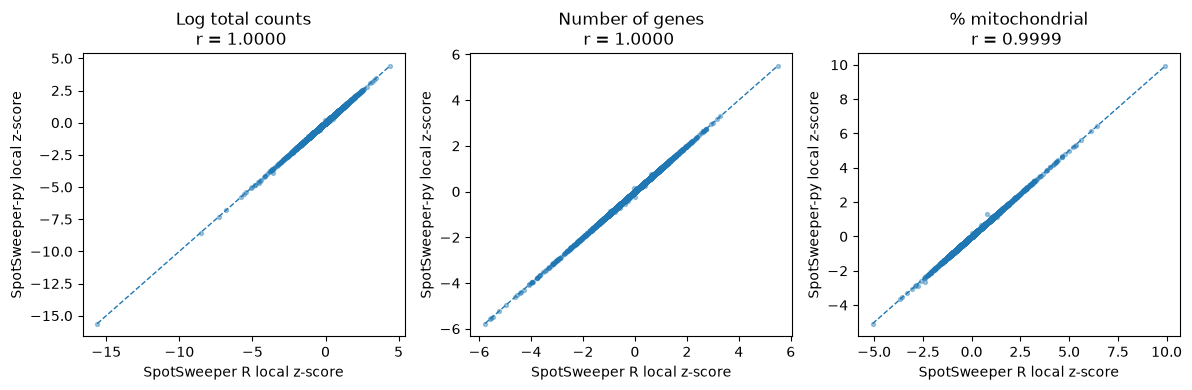

In [9]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
)


for ax, metric in zip(
    axes,
    METRICS,
):

    x = comparison[
        f"{metric}_z_r"
    ].to_numpy()

    y = comparison[
        f"{metric}_z_python"
    ].to_numpy()


    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.4,
    )


    lower = min(
        np.nanmin(x),
        np.nanmin(y),
    )

    upper = max(
        np.nanmax(x),
        np.nanmax(y),
    )


    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1,
    )


    stats = concordance.loc[
        concordance["metric"] == metric
    ].iloc[0]


    ax.set_title(
        f"{METRIC_LABELS[metric]}\n"
        f"r = "
        f"{stats['z_score_pearson_r']:.4f} "
    )

    ax.set_xlabel(
        "SpotSweeper R local z-score"
    )

    ax.set_ylabel(
        "SpotSweeper-py local z-score"
    )


plt.tight_layout()

plt.show()

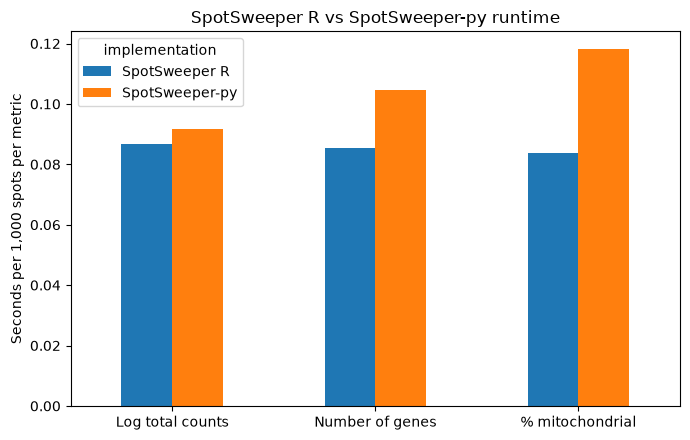

In [10]:
runtime_plot = (
    runtime_summary[
        [
            "implementation",
            "metric",
            "median_seconds_per_1000_spots",
        ]
    ]
    .pivot(
        index="metric",
        columns="implementation",
        values="median_seconds_per_1000_spots",
    )
    .loc[METRICS]
)


runtime_plot.index = [
    METRIC_LABELS[x]
    for x in runtime_plot.index
]


ax = runtime_plot.plot(
    kind="bar",
    figsize=(7, 4.5),
)


ax.set_xlabel("")

ax.set_ylabel(
    "Seconds per 1,000 spots per metric"
)

ax.set_title(
    "SpotSweeper R vs SpotSweeper-py runtime"
)

ax.tick_params(
    axis="x",
    rotation=0,
)


plt.tight_layout()

plt.show()

Final export

Saved final figure to:
/users/xchen5/revisions_SpotSweeper-py/figures/Figure_R_vs_Python_benchmark.tif


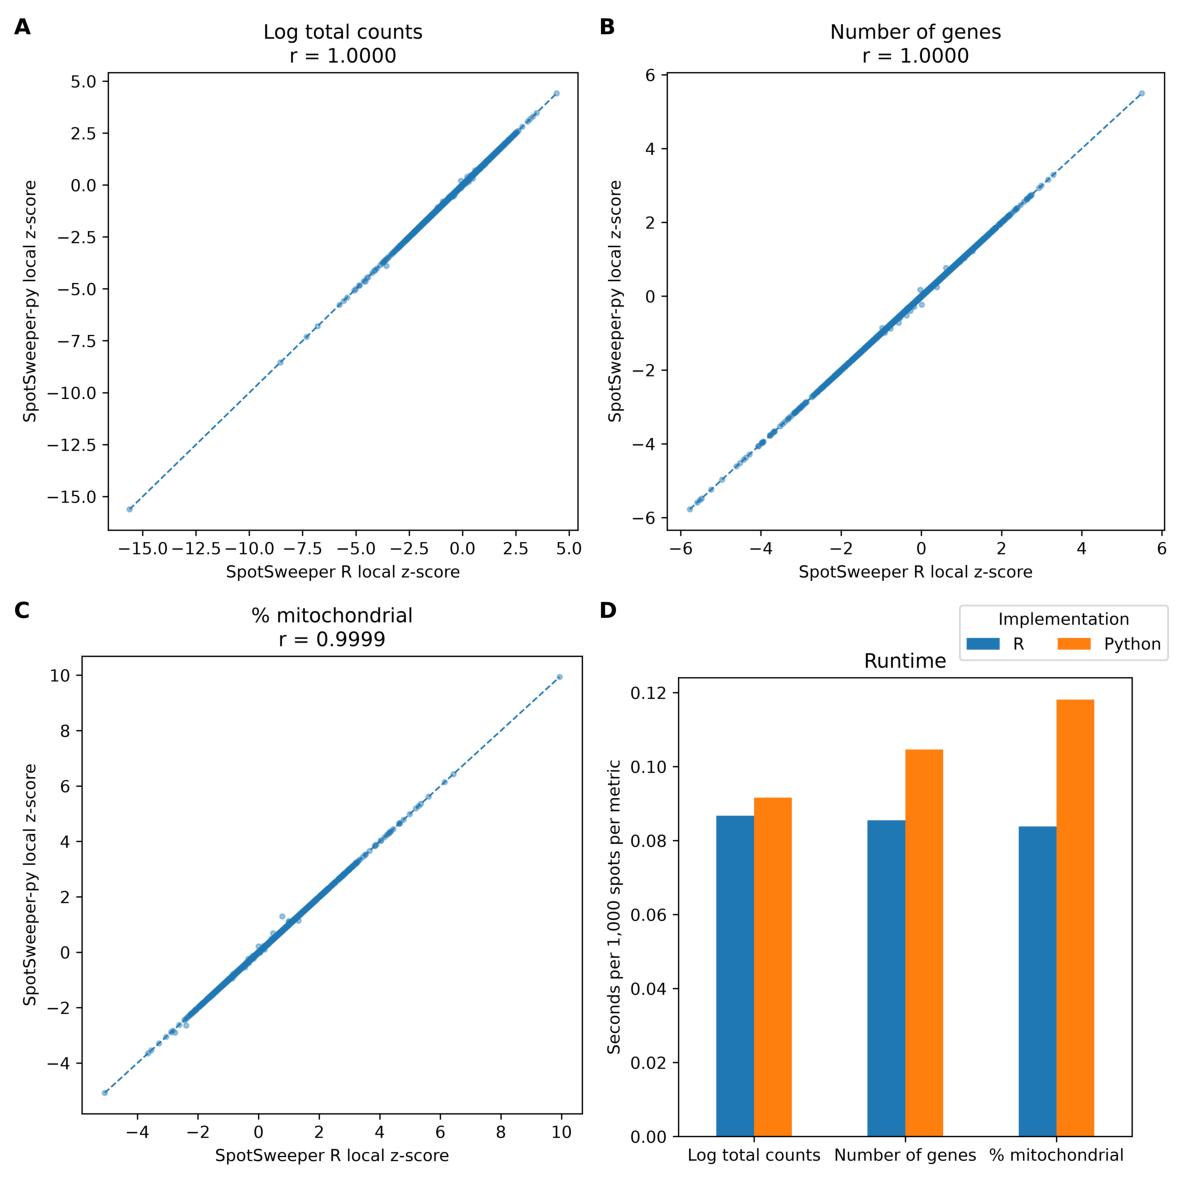

In [11]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import numpy as np

OUTDIR = "/users/xchen5/revisions_SpotSweeper-py/figures"


# ============================================================
# PANELS A-C: R vs Python local z-score concordance
# ============================================================

panel_files = []

for panel_label, metric in zip(
    ["A", "B", "C"],
    METRICS,
):
    fig, ax = plt.subplots(figsize=(5, 5))

    x = comparison[
        f"{metric}_z_r"
    ].to_numpy()

    y = comparison[
        f"{metric}_z_python"
    ].to_numpy()

    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.4,
    )

    lower = min(
        np.nanmin(x),
        np.nanmin(y),
    )

    upper = max(
        np.nanmax(x),
        np.nanmax(y),
    )

    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1,
    )

    stats = concordance.loc[
        concordance["metric"] == metric
    ].iloc[0]

    ax.set_title(
        f"{METRIC_LABELS[metric]}\n"
        f"r = {stats['z_score_pearson_r']:.4f}"
    )

    ax.set_xlabel(
        "SpotSweeper R local z-score"
    )

    ax.set_ylabel(
        "SpotSweeper-py local z-score"
    )

    plt.tight_layout()

    panel_path = (
        f"{OUTDIR}/Benchmark_panel_{panel_label}.png"
    )

    fig.savefig(
        panel_path,
        dpi=600,
        bbox_inches="tight",
    )

    plt.close(fig)

    panel_files.append(panel_path)


# ============================================================
# PANEL D: runtime comparison
# ============================================================

runtime_plot = (
    runtime_summary[
        [
            "implementation",
            "metric",
            "median_seconds_per_1000_spots",
        ]
    ]
    .pivot(
        index="metric",
        columns="implementation",
        values="median_seconds_per_1000_spots",
    )
    .loc[METRICS]
)

runtime_plot.index = [
    METRIC_LABELS[x]
    for x in runtime_plot.index
]


figD, ax = plt.subplots(figsize=(5, 5))

runtime_plot.plot(
    kind="bar",
    ax=ax,
)

ax.set_xlabel("")

ax.set_ylabel(
    "Seconds per 1,000 spots per metric"
)

ax.set_title(
    "Runtime"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    ["R", "Python"],
    title="Implementation",
    loc="lower center",
    bbox_to_anchor=(0.85, 1.02),
    ncol=2,
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    edgecolor="lightgray",
)

plt.tight_layout()

panel_D_path = (
    f"{OUTDIR}/Benchmark_panel_D.png"
)

figD.savefig(
    panel_D_path,
    dpi=600,
    bbox_inches="tight",
)

plt.close(figD)


# ============================================================
# LOAD PANELS
# ============================================================

A = Image.open(
    f"{OUTDIR}/Benchmark_panel_A.png"
).convert("RGB")

B = Image.open(
    f"{OUTDIR}/Benchmark_panel_B.png"
).convert("RGB")

C = Image.open(
    f"{OUTDIR}/Benchmark_panel_C.png"
).convert("RGB")

D = Image.open(
    f"{OUTDIR}/Benchmark_panel_D.png"
).convert("RGB")


# ============================================================
# RESIZE PANELS TO COMMON DIMENSIONS
# ============================================================

target_w = max(
    A.width,
    B.width,
    C.width,
    D.width,
)

target_h = max(
    A.height,
    B.height,
    C.height,
    D.height,
)


def fit_panel(im, target_w, target_h):
    """
    Resize image while preserving aspect ratio, then center
    on a white canvas of identical dimensions.
    """

    scale = min(
        target_w / im.width,
        target_h / im.height,
    )

    new_w = int(im.width * scale)
    new_h = int(im.height * scale)

    resized = im.resize(
        (new_w, new_h),
        Image.Resampling.LANCZOS,
    )

    canvas = Image.new(
        "RGB",
        (target_w, target_h),
        "white",
    )

    x_offset = (
        target_w - new_w
    ) // 2

    y_offset = (
        target_h - new_h
    ) // 2

    canvas.paste(
        resized,
        (x_offset, y_offset),
    )

    return canvas


A = fit_panel(
    A,
    target_w,
    target_h,
)

B = fit_panel(
    B,
    target_w,
    target_h,
)

C = fit_panel(
    C,
    target_w,
    target_h,
)

D = fit_panel(
    D,
    target_w,
    target_h,
)


# ============================================================
# STITCH 2 x 2
# ============================================================

W = 2 * target_w
H = 2 * target_h

out = Image.new(
    "RGB",
    (W, H),
    "white",
)

out.paste(
    A,
    (0, 0),
)

out.paste(
    B,
    (target_w, 0),
)

out.paste(
    C,
    (0, target_h),
)

out.paste(
    D,
    (target_w, target_h),
)


# ============================================================
# PANEL LABELS
# ============================================================

draw = ImageDraw.Draw(out)

try:
    font = ImageFont.truetype(
        "DejaVuSans-Bold.ttf",
        size=110,
    )
except IOError:
    font = ImageFont.load_default()


def label(x, y, text):
    pad = 10

    bbox = draw.textbbox(
        (x, y),
        text,
        font=font,
    )

    draw.rectangle(
        (
            bbox[0] - pad,
            bbox[1] - pad,
            bbox[2] + pad,
            bbox[3] + pad,
        ),
        fill="white",
    )

    draw.text(
        (x, y),
        text,
        fill="black",
        font=font,
    )


margin = 20

label(
    margin,
    margin,
    "A",
)

label(
    target_w + margin,
    margin,
    "B",
)

label(
    margin,
    target_h + margin,
    "C",
)

label(
    target_w + margin,
    target_h + margin,
    "D",
)


# ============================================================
# FINAL TIFF EXPORT
# ============================================================

FINAL_PATH = (
    f"{OUTDIR}/Figure_R_vs_Python_benchmark.tif"
)

out.save(
    FINAL_PATH,
    dpi=(300, 300),
    compression="tiff_lzw",
)

print(
    f"Saved final figure to:\n{FINAL_PATH}"
)


# ============================================================
# DISPLAY FINAL FIGURE
# ============================================================

plt.figure(
    figsize=(12, 12)
)

plt.imshow(out)

plt.axis("off")

plt.tight_layout()

plt.show()